**Hidden State Update** - 

h_t = tanh((w_xh. x_t) + (w_hh. h_x-1) + b_h)

**Output** - 

o_t = w_hy + b_y

y_t = softmax(o_t)

### class torch.nn.RNN(input_size, hidden_size, num_layers=1, nonlinearity='tanh', bias=True, batch_first=False, dropout=0.0, bidirectional=False, device=None, dtype=None)

#### Using Numpy

In [1]:
import numpy as np

def one_hot(index, size):
    v = np.zeros((size, 1))
    v[index] = 1.0
    return v
def make_parity_sequence(T):
    xs = []
    ys = []
    count_ones = 0
    for t in range(T):
        bit = np.random.randint(0, 2)
        xs.append(one_hot(bit, 2))
        count_ones += bit
        parity = count_ones % 2  # 0 even, 1 odd
        ys.append(parity)
    return xs, ys


In [5]:
import numpy as np

class RNN_scrach:
    def __init__(self, il, hl, ol):
        self.il = il
        self.hl = hl
        self.ol = ol

        scale = 0.1
        self.Wxh = np.random.randn(self.hl, self.il) * scale
        self.Whh = np.random.randn(self.hl, self.hl) * scale
        self.Why = np.random.randn(self.ol, self.hl) * scale
        self.bh = np.zeros((self.hl, 1))
        self.by = np.zeros((self.ol, 1))

    def forward(self, inputs, h_prev=None):
        if h_prev is None:
            h_prev = np.zeros((self.hl, 1))

        T = len(inputs)
        hs = {-1: h_prev}
        os = {}
        ys = {}

        for t in range(T):
            xt = inputs[t]   # shape: (input_size, 1)

            hs[t] = np.tanh(
                np.dot(self.Wxh, xt) +
                np.dot(self.Whh, hs[t - 1]) +
                self.bh
            )

            os[t] = np.dot(self.Why, hs[t]) + self.by
            exp_o = np.exp(os[t] - np.max(os[t]))
            ys[t] = exp_o / np.sum(exp_o)

        return ys, hs, os

    def loss(self, ys, targets):
        T = len(targets)
        L = 0.0
        for t in range(T):
            L += -np.log(ys[t][targets[t], 0] + 1e-9)
        return L / T

    def backward(self, inputs, hs, ys, os, targets):
        T = len(inputs)

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh  = np.zeros_like(self.bh)
        dWhy = np.zeros_like(self.Why)
        dby  = np.zeros_like(self.by)

        dh_next = np.zeros((self.hl, 1))

        for t in reversed(range(T)):
            dy = np.copy(ys[t])
            dy[targets[t], 0] -= 1.0

            dWhy += np.dot(dy, hs[t].T)
            dby  += dy

            dh = np.dot(self.Why.T, dy) + dh_next
            dh_raw = (1 - hs[t] ** 2) * dh

            dbh  += dh_raw
            dWxh += np.dot(dh_raw, inputs[t].T)
            dWhh += np.dot(dh_raw, hs[t - 1].T)

            dh_next = np.dot(self.Whh.T, dh_raw)

        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)

        return dWxh, dWhh, dWhy, dbh, dby

    def step(self, grads, lr=0.1):
        dWxh, dWhh, dWhy, dbh, dby = grads
        self.Wxh -= lr * dWxh
        self.Whh -= lr * dWhh
        self.Why -= lr * dWhy
        self.bh  -= lr * dbh
        self.by  -= lr * dby

In [ ]:
np.random.seed(0)

input_size = 2
hidden_size = 8
output_size = 2
seq_len = 8
model = RNN_scrach(input_size, hidden_size, output_size)

for epoch in range(2000):
    xs, targets = make_parity_sequence(seq_len)
    ys, hs, os = model.forward(xs)
    loss = model.loss(ys, targets)
    grads = model.backward(xs, hs, ys, os, targets)
    model.step(grads, lr=0.1)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, loss {loss:.4f}")

xs, targets = make_parity_sequence(seq_len)
ys, hs, os = model.forward(xs)

print("targets:", targets)
for t in range(seq_len):
    print(t, "hidden[0]:", hs[t][0, 0])



Epoch 0, loss 0.6945
Epoch 100, loss 0.7357
Epoch 200, loss 0.7233
Epoch 300, loss 0.7308
Epoch 400, loss 0.6985
Epoch 500, loss 0.6949
Epoch 600, loss 0.6550
Epoch 700, loss 0.6983
Epoch 800, loss 0.7291
Epoch 900, loss 0.7114
Epoch 1000, loss 0.7008
Epoch 1100, loss 1.1041
Epoch 1200, loss 0.6692
Epoch 1300, loss 0.9352
Epoch 1400, loss 1.2185
Epoch 1500, loss 0.8241
Epoch 1600, loss 1.0048
Epoch 1700, loss 0.8754
Epoch 1800, loss 0.7958
Epoch 1900, loss 0.2348
targets: [1, 0, 1, 0, 0, 1, 0, 1]
0 hidden[0]: -0.8092960724606271
1 hidden[0]: 0.9999931716194391
2 hidden[0]: 0.940580522594609
3 hidden[0]: 0.9999177352783505
4 hidden[0]: 0.9999999171717053
5 hidden[0]: 0.9999999939448957
6 hidden[0]: 0.9997107244260084
7 hidden[0]: 0.9999999939358223


#### Using PyTorch

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
from torch.utils.data import Dataset, DataLoader


class SineWaveDataset(Dataset):
    def __init__(self, seq_length=20, num_samples=1000, step=0.1):
        """
        seq_length: length of input sequence
        num_samples: number of training samples
        step: spacing between sine wave points
        """
        self.seq_length = seq_length
        self.num_samples = num_samples
        self.step = step

        self.x_data = []
        self.y_data = []

        for i in range(num_samples):
            start = i * step
            time_steps = torch.linspace(start, start + seq_length * step, steps=seq_length + 1)
            wave = torch.sin(time_steps)

            # Input: first seq_length points
            x_seq = wave[:-1].unsqueeze(-1)   # shape: (seq_length, 1)

            # Target: next seq_length points
            y_seq = wave[1:].unsqueeze(-1)    # shape: (seq_length, 1)

            self.x_data.append(x_seq)
            self.y_data.append(y_seq)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.x_data[idx], self.y_data[idx]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Example usage
seq_length = 30
dataset = SineWaveDataset(seq_length=seq_length, num_samples=1000, step=0.1)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print("Dataset size:", len(dataset))
# Check one batch
for x_batch, y_batch in dataloader:
    print("Input shape :", x_batch.shape)   # (batch_size, seq_length, 1)
    print("Target shape:", y_batch.shape)   # (batch_size, seq_length, 1)
    break

Using device: cuda
Dataset size: 1000
Input shape : torch.Size([32, 30, 1])
Target shape: torch.Size([32, 30, 1])


In [4]:
class VanillaRNN(nn.Module):
    def __init__(self, il = 1, hl = 16, ol = 1):
        super(VanillaRNN, self).__init__()

        self.rnn = nn.RNN(input_size=il, hidden_size=hl, batch_first=True)
        self.fc = nn.Linear(hl, ol)

    def forward(self, x):
        out, hn = self.rnn(x)
        out = self.fc(out)
        return out
    



In [10]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

trainset, valset = random_split(dataset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader = DataLoader(valset, batch_size=32, shuffle=False)

model = VanillaRNN(1, 32, 1).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.005)

num_epoch = 5

for epoch in range(num_epoch):
    model.train()
    total_loss = 0.0

    for inputs, labels in trainloader:
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(inputs)   # shape: (batch, seq_len, 1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(trainloader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.6f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device).float()
            labels = labels.to(device).float()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(valloader)
    print(f"Epoch {epoch+1}, Validation Loss: {avg_val_loss:.6f}")

Epoch 1, Train Loss: 0.150254
Epoch 1, Validation Loss: 0.024837
Epoch 2, Train Loss: 0.017540
Epoch 2, Validation Loss: 0.013061
Epoch 3, Train Loss: 0.010107
Epoch 3, Validation Loss: 0.008971
Epoch 4, Train Loss: 0.007540
Epoch 4, Validation Loss: 0.007211
Epoch 5, Train Loss: 0.006114
Epoch 5, Validation Loss: 0.005940


#### **Application** - Predict Characters

In [1]:
import torch
import torch.nn as nn
import numpy as np

import urllib.request

# 1. Download the Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
filename = "shakespeare.txt"
urllib.request.urlretrieve(url, filename)

# 2. Read the text file into a string
with open(filename, 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Length of dataset in characters: {len(text)}")

# 3. For a quick 2-hour learning session, let's slice the first 10,000 characters. 
# (Training on the full 1 million characters takes much longer!)
#text = text[:10000]

# 4. Build the vocabulary exactly as we did before
chars = list(set(text))
vocab_size = len(chars)

char_to_ix = {ch: i for i, ch in enumerate(chars)}
ix_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Vocabulary size: {vocab_size} unique characters")

Length of dataset in characters: 1115394
Vocabulary size: 65 unique characters


In [2]:
def text_to_onehot(string):
    tensor = torch.zeros(len(string), vocab_size)
    for i, char in enumerate(string):
        tensor[i, char_to_ix[char]] = 1.0
    return tensor

def text_to_indices(string):
    """Converts a string to a tensor of integer indices."""
    indices = [char_to_ix[char] for char in string]
    return torch.tensor(indices, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
class charRNN(nn.Module):
    def __init__(self, il,hl, ol):
        super(charRNN, self).__init__()
        self.rnn = nn.RNN(
            input_size= il,
            hidden_size = hl,
            batch_first = True,
        )
        self.fc = nn.Linear(hl, ol)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# ----------------------------
# Hyperparameters
# ----------------------------
hl = 16
num_epoch = 20
batch_size = 64
seq_len = 20
lr = 0.01

# ----------------------------
# Model
# ----------------------------
model = charRNN(vocab_size, hl, vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

# ----------------------------
# Build dataset
# ----------------------------
samples = []
for i in range(len(text) - seq_len):
    input_seq = text[i:i+seq_len]
    target_seq = text[i+1:i+seq_len+1]

    input_tensor = text_to_onehot(input_seq)
    target_tensor = text_to_indices(target_seq)

    samples.append((input_tensor, target_tensor))

# ----------------------------
# Train/Validation split
# ----------------------------
train_size = int(0.8 * len(samples))
val_size = len(samples) - train_size

train_dataset, val_dataset = random_split(samples, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# ----------------------------
# Store metrics
# ----------------------------
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ----------------------------
# Weight tracking containers
# ----------------------------
weight_norm_history = {name: [] for name, param in model.named_parameters()}
weight_change_history = {name: [] for name, param in model.named_parameters()}

prev_params = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
}

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(num_epoch):
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        hidden = torch.zeros(1, inputs.size(0), hl).to(device)

        optimizer.zero_grad()

        outputs, hidden = model(inputs, hidden)

        outputs_flat = outputs.reshape(-1, vocab_size)
        labels_flat = labels.reshape(-1)

        loss = criterion(outputs_flat, labels_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()

        running_train_loss += loss.item()

        preds = torch.argmax(outputs_flat, dim=1)
        train_correct += (preds == labels_flat).sum().item()
        train_total += labels_flat.size(0)

    epoch_train_loss = running_train_loss / len(trainloader)
    epoch_train_acc = train_correct / train_total

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ---- Validation ----
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            hidden = torch.zeros(1, inputs.size(0), hl).to(device)

            outputs, hidden = model(inputs, hidden)

            outputs_flat = outputs.reshape(-1, vocab_size)
            labels_flat = labels.reshape(-1)

            loss = criterion(outputs_flat, labels_flat)
            running_val_loss += loss.item()

            preds = torch.argmax(outputs_flat, dim=1)
            val_correct += (preds == labels_flat).sum().item()
            val_total += labels_flat.size(0)

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # ---- Track weights after each epoch ----
    with torch.no_grad():
        for name, param in model.named_parameters():
            # L2 norm of current weights
            weight_norm_history[name].append(param.norm().item())

            # Mean absolute change from previous epoch
            change = (param - prev_params[name]).abs().mean().item()
            weight_change_history[name].append(change)

            # Update stored previous parameter
            prev_params[name] = param.detach().clone()

    print(
        f"Epoch {epoch+1}/{num_epoch} | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )



Epoch 1/20 | Train Loss: 2.1417 | Train Acc: 0.3798 | Val Loss: 2.1103 | Val Acc: 0.3872
Epoch 2/20 | Train Loss: 2.1029 | Train Acc: 0.3902 | Val Loss: 2.1056 | Val Acc: 0.3926
Epoch 3/20 | Train Loss: 2.0987 | Train Acc: 0.3914 | Val Loss: 2.0992 | Val Acc: 0.3914
Epoch 4/20 | Train Loss: 2.0959 | Train Acc: 0.3916 | Val Loss: 2.0960 | Val Acc: 0.3897
Epoch 5/20 | Train Loss: 2.0944 | Train Acc: 0.3914 | Val Loss: 2.0961 | Val Acc: 0.3902
Epoch 6/20 | Train Loss: 2.0934 | Train Acc: 0.3918 | Val Loss: 2.0961 | Val Acc: 0.3920
Epoch 7/20 | Train Loss: 2.0918 | Train Acc: 0.3918 | Val Loss: 2.0931 | Val Acc: 0.3917
Epoch 8/20 | Train Loss: 2.0906 | Train Acc: 0.3918 | Val Loss: 2.0963 | Val Acc: 0.3889
Epoch 9/20 | Train Loss: 2.0903 | Train Acc: 0.3920 | Val Loss: 2.0913 | Val Acc: 0.3921
Epoch 10/20 | Train Loss: 2.0903 | Train Acc: 0.3921 | Val Loss: 2.0908 | Val Acc: 0.3909
Epoch 11/20 | Train Loss: 2.0901 | Train Acc: 0.3922 | Val Loss: 2.0944 | Val Acc: 0.3890
Epoch 12/20 | Train

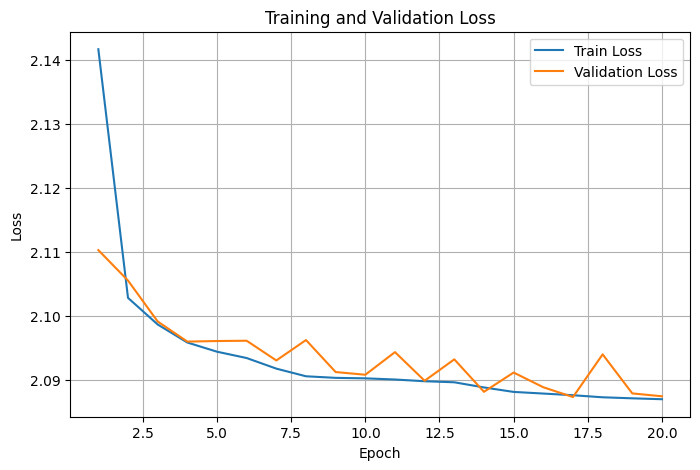

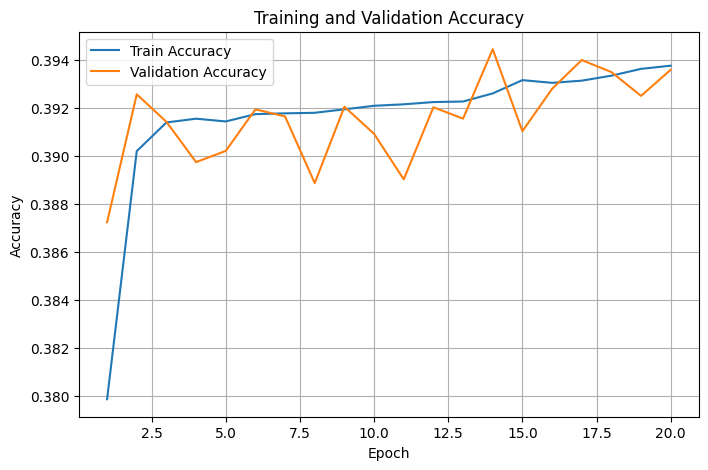

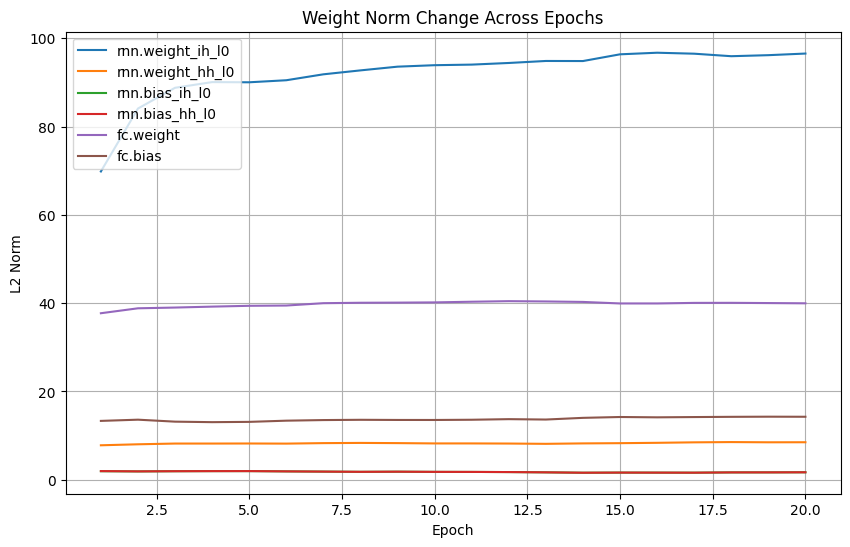

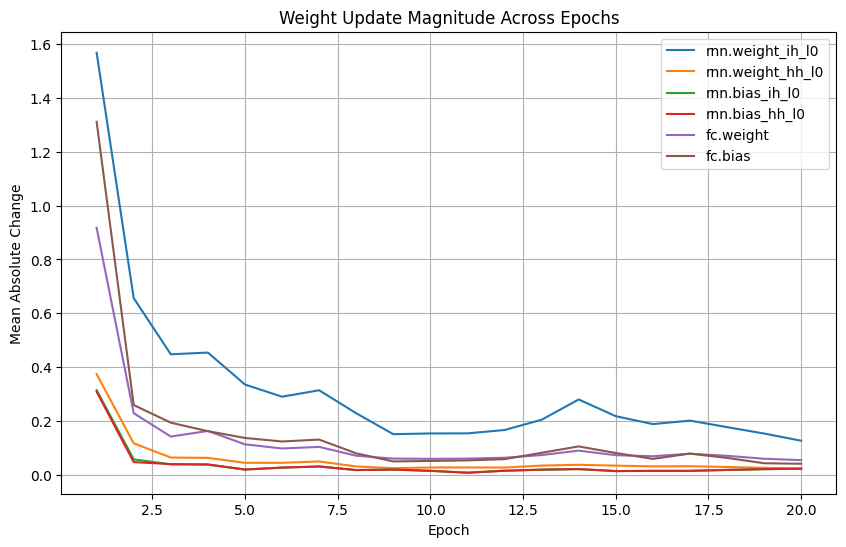

In [5]:
# ----------------------------
# Plot Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epoch + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epoch + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epoch + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epoch + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot Weight Norms
# ----------------------------
plt.figure(figsize=(10, 6))
for name, values in weight_norm_history.items():
    plt.plot(range(1, num_epoch + 1), values, label=name)
plt.xlabel("Epoch")
plt.ylabel("L2 Norm")
plt.title("Weight Norm Change Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------
# Plot Mean Absolute Weight Change
# ----------------------------
plt.figure(figsize=(10, 6))
for name, values in weight_change_history.items():
    plt.plot(range(1, num_epoch + 1), values, label=name)
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Change")
plt.title("Weight Update Magnitude Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
def generate_text(model, start_char, predict_len=10):
    model.eval()
    current_char = start_char
    generated_text = start_char

    hidden = torch.zeros(1, 1, hl).to(device)

    with torch.no_grad():
        for _ in range(predict_len):
            x = text_to_onehot(current_char).unsqueeze(0).to(device)   # (1, 1, vocab_size)

            output, hidden = model(x, hidden)

            predicted_index = torch.argmax(output[0, -1]).item()
            current_char = ix_to_char[predicted_index]

            generated_text += current_char

    return generated_text

print("\nGenerated sequence:")
print(generate_text(model, start_char='p', predict_len=20))


Generated sequence:
per the the the the t
